# LongitudinalRESIT

**LongitudinalRESIT** is a causal discovery algorithm for **longitudinal (time-series) data**, extending the **RESIT (Regression with Subsequent Independence Test)** framework to handle nonlinear relationships and temporal dependencies.

The method estimates both **instantaneous (within-time)** and **lagged (across-time)** causal structures from multivariate time-series data. It operates in three phases: 
- **Phase1:** estimating a causal order via repeated sink node detection (the estimated causal order is assumed to be shared across all time points)
- **Phase2:** estimating instantaneous causal graphs through regression-based independence testing with edge pruning
- **Phase3:** identifying lagged causal relationships by testing dependencies between past and present variables.

A key feature of LongitudinalRESIT is its ability to integrate information across multiple time points. It uses Fisher’s method to combine independence test results over time, enabling robust inference of causal structure even under temporal variability. The algorithm also supports both shared causal graphs across time and time-specific causal structures, depending on the analysis setting. By leveraging nonlinear regression models and kernel-based independence tests (HSIC), LongitudinalRESIT can capture complex causal mechanisms beyond linear assumptions.

## Import and settings

In this example, we need to import numpy, pandas, and graphviz in addition to lingam.

In [1]:
import re
import random
import numpy as np
import pandas as pd
import graphviz
from IPython.display import display, HTML

from scipy.stats import norm, uniform
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

import lingam
import lingam.utils

import warnings
warnings.filterwarnings('ignore')

print([np.__version__, pd.__version__, graphviz.__version__, lingam.__version__])

['1.26.4', '2.2.3', '0.20.3', '1.12.2']


In [2]:
np.set_printoptions(precision=3, suppress=True)
seed = 123
random.seed(seed)
np.random.seed(seed)

In [3]:
_NONLINEAR_FUNCS = {
    "tanh":     lambda x: np.tanh(x),
    "softsign": lambda x: x / (1.0 + np.abs(x)),
    "atan":     lambda x: np.arctan(x) * (2.0 / np.pi),
    "sigmoid":  lambda x: 2.0 / (1.0 + np.exp(-x)) - 1,
}
_NONLINEAR_FUNC_NAMES = list(_NONLINEAR_FUNCS.keys())

def _random_nonlinear(rng):
    name = _NONLINEAR_FUNC_NAMES[rng.integers(len(_NONLINEAR_FUNC_NAMES))]
    return name, _NONLINEAR_FUNCS[name]

def generate_causal_order(n_vars, rng):
    """Return a random causal order (the first element is the most upstream)."""
    return rng.permutation(n_vars).tolist()

def generate_dag(n_vars, causal_order, edge_prob, rng):
    """Generate a random DAG consistent with the causal order. B[j, i] = 1 denotes i → j."""
    B = np.zeros((n_vars, n_vars), dtype=float)
    for pos_j, j in enumerate(causal_order):
        for pos_i in range(pos_j):
            i = causal_order[pos_i]
            if rng.random() < edge_prob:
                B[j, i] = 1.0
    return B

def generate_lag_graph(n_lags, n_vars, edge_prob, rng):
    """Generate a random lagged causal graph. A[k, j, i] = 1 denotes i → j at (k+1) time steps lag."""
    return (rng.random((n_lags, n_vars, n_vars)) < edge_prob).astype(float)

def generate_longitudinal_data(B_list, A_list, causal_order, n_samples, T, n_lags, rng):
    """Generate longitudinal data X_list using a nonlinear ANM.
    Randomly assign tanh / softsign / atan / sigmoid to each edge,
    and add independent noise Uniform(-1, 1) for each variable and time point.
    Remove the initial n_lags time steps as a warm-up.
    """
    n_vars = B_list[0].shape[0]
    is_common = (len(B_list) == 1)
    X_list = []

    func_labels_B, func_labels_A = {}, {}
    for B_ref in B_list:
        for j in range(n_vars):
            for i in range(n_vars):
                if B_ref[j, i] == 1.0 and (j, i) not in func_labels_B:
                    name, _ = _random_nonlinear(rng)
                    func_labels_B[(j, i)] = name
    for A_ref in A_list:
        for k in range(n_lags):
            for j in range(n_vars):
                for i in range(n_vars):
                    if A_ref[k, j, i] == 1.0 and (k, j, i) not in func_labels_A:
                        name, _ = _random_nonlinear(rng)
                        func_labels_A[(k, j, i)] = name

    for t in range(T + n_lags):
        graph_idx = max(0, t - n_lags)
        B = B_list[0] if is_common else B_list[graph_idx]
        A = A_list[0] if is_common else A_list[graph_idx]
        X_t = np.zeros((n_samples, n_vars))
        for j in causal_order:
            x_j = rng.uniform(-1.0, 1.0, size=n_samples)
            for i in range(n_vars):
                if B[j, i] == 1.0:
                    x_j += _NONLINEAR_FUNCS[func_labels_B[(j, i)]](X_t[:, i])
            for k in range(n_lags):
                prev_t = t - (k + 1)
                if prev_t >= 0:
                    for i in range(n_vars):
                        if A[k, j, i] == 1.0:
                            x_j += _NONLINEAR_FUNCS[func_labels_A[(k, j, i)]](X_list[prev_t][:, i])
            X_t[:, j] = x_j
        X_list.append(X_t)

    return X_list[n_lags:]

def make_longitudinal_dot(B_list, A_list, T, n_lags, labels=None):
    """Arrange variables vertically (x0, …) and time horizontally from left to right (t = 0, …).
    Solid lines: instantaneous edges; dashed (blue): lagged edges.
    """
    n_vars = B_list[0].shape[0]
    is_common = (len(B_list) == 1)
    if labels is None:
        labels = [f"x{i}" for i in range(n_vars)]

    def nid(i, t):
        return f"n{i}_{t}"

    dot = graphviz.Digraph(engine="dot")

    dot.attr(
        newrank="true",
        splines="spline",
        # rankdir="LR",
        ranksep="0.15",
        nodesep="0.08"
    )

    dot.attr(
        "node",
        shape="ellipse",
        width="0.45",
        height="0.28",
        fontsize="10",
        margin="0.03,0.02"
    )

    dot.attr("edge", arrowsize="0.5")

    for t in range(T):
        with dot.subgraph(name=f"cluster_t{t}") as s:
            s.attr(label=f"t = {t}", style="rounded", color="gray", bgcolor="white")
            for i in range(n_vars):
                s.node(nid(i, t), label=labels[i])

    for i in range(n_vars):
        with dot.subgraph() as s:
            s.attr(rank="same")
            for t in range(T):
                s.node(nid(i, t))

    for t in range(T):
        for i in range(n_vars - 1):
            dot.edge(nid(i, t), nid(i + 1, t), style="invis")

    for t in range(T):
        B = B_list[0] if is_common else B_list[t]
        if np.any(np.isnan(B)):
            continue
        for j in range(n_vars):
            for i in range(n_vars):
                if B[j, i] == 1.0:
                    dot.edge(nid(i, t), nid(j, t))

    for t in range(n_lags, T):
        A = A_list[0] if is_common else A_list[t]
        if np.any(np.isnan(A)):
            continue
        for k in range(n_lags):
            for j in range(n_vars):
                for i in range(n_vars):
                    if A[k, j, i] == 1.0:
                        dot.edge(nid(i, t - k - 1), nid(j, t),
                                 style="dashed", color="steelblue")

    return dot

## Causal graph shared across all time points

### Test data

We generate a causal structure with 5 variables, 5 time points, and a lag of 1, such that the causal graph is shared across all time points.

Causal order: [4, 0, 2, 3, 1]

Generated 5 time points, each shape = (1000, 5)


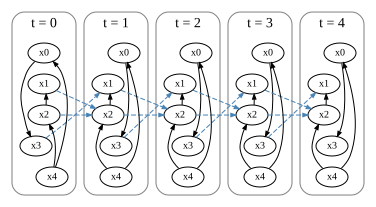

In [4]:
n_vars    = 5
n_lags    = 1
T         = 5
n_samples = 1000
edge_prob = 0.5

# Adjust the probability so that the expected number of lagged edges matches that of instantaneous edges.
lag_edge_prob = edge_prob * (n_vars - 1) / (2 * n_lags * n_vars)

rng = np.random.default_rng(seed)

causal_order = generate_causal_order(n_vars, rng)
B_true = generate_dag(n_vars, causal_order, edge_prob, rng)
A_true = generate_lag_graph(n_lags, n_vars, lag_edge_prob, rng)

labels = [f"x{i}" for i in range(n_vars)]
print("Causal order:", causal_order)

X_list = generate_longitudinal_data(
    [B_true], [A_true], causal_order, n_samples, T, n_lags, rng
)
print(f"\nGenerated {len(X_list)} time points, each shape = {X_list[0].shape}")

make_longitudinal_dot([B_true], [A_true], T, n_lags, labels=labels)

### Causal Discovery

To run causal discovery, we create a ``LongitudinalRESIT`` object and call the ``fit()`` method, with an option to estimate a causal graph that is **shared across all time points**.

* **is_common_graph**: True

Estimated causal order: [4, 0, 2, 1, 3]


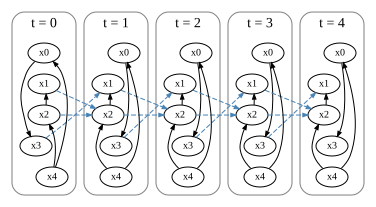

In [5]:
regressor = RandomForestRegressor(n_estimators=100, random_state=seed)
model = lingam.LongitudinalRESIT(
    regressor=regressor,
    n_lags=n_lags,
    is_common_graph=True,
)
model.fit(X_list)

print("Estimated causal order:", model.causal_order_)

make_longitudinal_dot(model.B_list_, model.A_list_, T, n_lags, labels=labels)

## Separate causal graphs for each time point

### Test data

We generate a causal structure with 5 variables, 5 time points, and a lag of 1, such that separate causal graphs are defined for each time point.

Causal order: [4, 0, 2, 3, 1]

Generated 5 time points, each shape = (1000, 5)


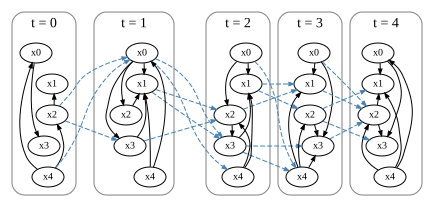

In [6]:
n_vars    = 5
n_lags    = 1
T         = 5
n_samples = 1000
edge_prob = 0.5

# Adjust the probability so that the expected number of lagged edges matches that of instantaneous edges.
lag_edge_prob = edge_prob * (n_vars - 1) / (2 * n_lags * n_vars)

rng = np.random.default_rng(seed)

causal_order = generate_causal_order(n_vars, rng)

B_list_true = []
A_list_true = []
for t in range(T):
    B_list_true.append(generate_dag(n_vars, causal_order, edge_prob, rng))
    A_list_true.append(generate_lag_graph(n_lags, n_vars, lag_edge_prob, rng))

labels = [f"x{i}" for i in range(n_vars)]
print("Causal order:", causal_order)

X_list = generate_longitudinal_data(
    B_list_true, A_list_true, causal_order, n_samples, T, n_lags, rng
)
print(f"\nGenerated {len(X_list)} time points, each shape = {X_list[0].shape}")

make_longitudinal_dot(B_list_true, A_list_true, T, n_lags, labels=labels)

## Causal Discovery

To run causal discovery, we create a ``LongitudinalRESIT`` object and call the ``fit()`` method, with an option to estimate **separate causal graphs for each time point**.

* **is_common_graph**: False

Estimated causal order: [4, 0, 2, 3, 1]


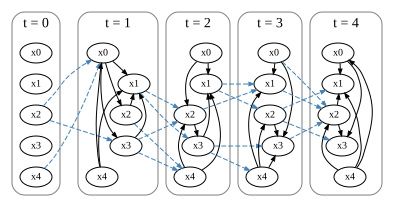

In [7]:
regressor = RandomForestRegressor(n_estimators=100, random_state=seed)
model = lingam.LongitudinalRESIT(
    regressor=regressor,
    n_lags=n_lags,
    is_common_graph=False,
)
model.fit(X_list)

print("Estimated causal order:", model.causal_order_)

make_longitudinal_dot(model.B_list_, model.A_list_, T, n_lags, labels=labels)